In [6]:
import pandas as pd

train_path = r"C:\Users\Admin\SentinelNet\data\processed\train_processed_advanced.csv"

df_train = pd.read_csv(train_path)

print(df_train.shape)

(336715, 55)


In [7]:
import pandas as pd

train_path = r"C:\Users\Admin\SentinelNet\data\processed\train_processed_advanced.csv"

df = pd.read_csv(train_path)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (336715, 55)


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH,attack_class
0,0.0,1.619565,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,normal
1,0.0,0.369565,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,normal
2,0.0,-0.159420,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,DoS
3,0.0,0.681159,15.800388,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,normal
4,0.0,0.561594,0.813953,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,normal


In [9]:
print(df.columns)

Index(['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
       'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
       'root_shell', 'su_attempted', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate', 'rerror_rate',
       'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
       'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_rerror_rate',
       'difficulty_level', 'is_outlier', 'log_duration', 'log_src_bytes',
       'log_dst_bytes', 'total_bytes', 'src_bytes_ratio', 'is_error_flag',
       'service_freq', 'protocol_type_icmp', 'protocol_type_tcp',
       'protocol_type_udp', 'flag_OTH', 'flag_REJ', 'flag_RSTO', 'flag_RSTOS0',
       'flag_RSTR', 'flag_S1', 'flag_S2', 'flag_S3', 'flag_SF', 'flag_SH',
     

In [10]:
target_column = df.columns[-1]

X = df.drop(columns=[target_column])
y = df[target_column]

print("Target column detected as:", target_column)

Target column detected as: attack_class


In [11]:
target_column = "attack_class"

X = df.drop(columns=[target_column])
y = df[target_column]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (336715, 54)
Target Shape: (336715,)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)

In [14]:
print(y.value_counts())

attack_class
normal    67343
DoS       67343
R2L       67343
Probe     67343
U2R       67343
Name: count, dtype: int64


In [15]:

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train_encoded)

print("Train Accuracy:", rf_model.score(X_train, y_train_encoded))
print("Test Accuracy:", rf_model.score(X_test, y_test_encoded))

Train Accuracy: 0.9993837518376075
Test Accuracy: 0.9991981349212242


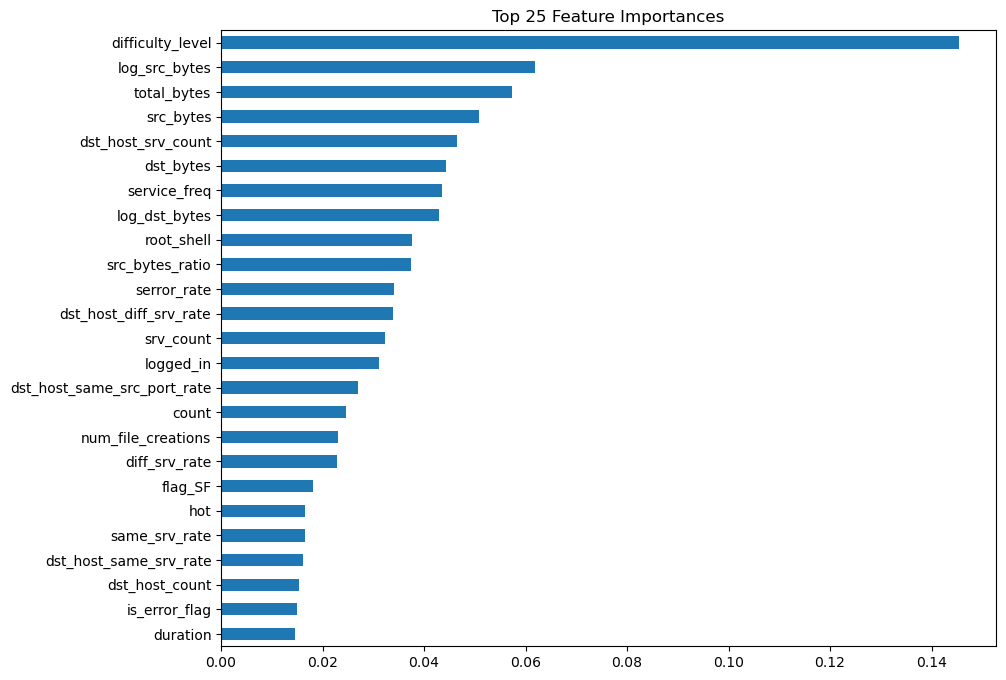

In [16]:
import matplotlib.pyplot as plt

importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,8))
importance.head(25).plot(kind='barh')
plt.title("Top 25 Feature Importances")
plt.gca().invert_yaxis()
plt.show()

In [17]:
threshold_value = 0.001

low_importance_features = importance[importance < threshold_value].index.tolist()

print("Low importance feature count:", len(low_importance_features))

X_train_reduced = X_train.drop(columns=low_importance_features)
X_test_reduced  = X_test.drop(columns=low_importance_features)

Low importance feature count: 13


In [18]:
rf_final = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_reduced, y_train_encoded)

print("Final Train Accuracy:", rf_final.score(X_train_reduced, y_train_encoded))
print("Final Test Accuracy:", rf_final.score(X_test_reduced, y_test_encoded))

Final Train Accuracy: 1.0
Final Test Accuracy: 0.999866355820204


In [19]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf_final.predict(X_test_reduced)

print("Classification Report:\n")
print(classification_report(y_test_encoded, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test_encoded, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00     13468
           2       1.00      1.00      1.00     13469
           3       1.00      1.00      1.00     13469
           4       1.00      1.00      1.00     13468

    accuracy                           1.00     67343
   macro avg       1.00      1.00      1.00     67343
weighted avg       1.00      1.00      1.00     67343

Confusion Matrix:

[[13469     0     0     0     0]
 [    0 13468     0     0     0]
 [    0     0 13469     0     0]
 [    0     0     0 13469     0]
 [    3     3     1     2 13459]]


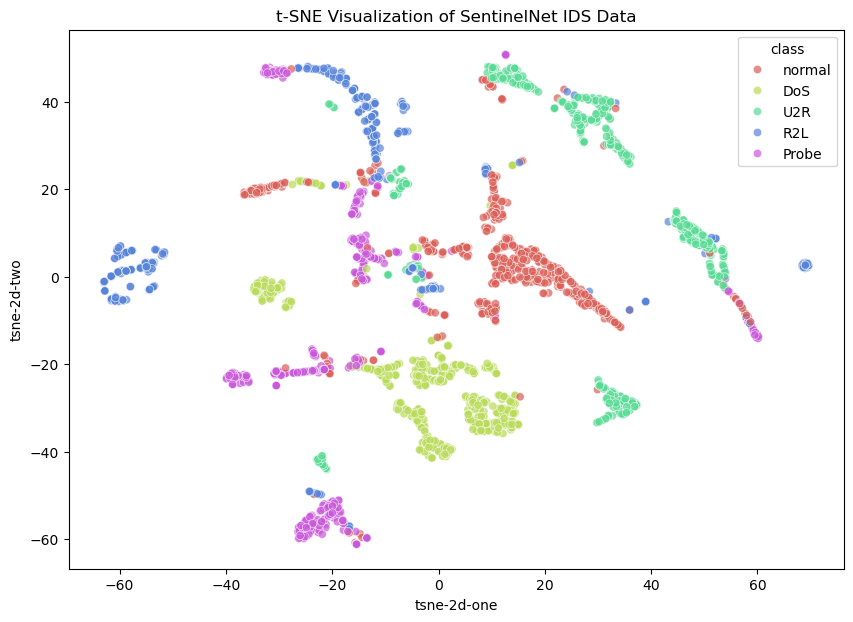

In [23]:
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sample_size = 3000
n_samples = min(sample_size, X_train_reduced.shape[0])

rows = np.random.choice(X_train_reduced.shape[0], n_samples, replace=False)

x_sample = X_train_reduced.iloc[rows]
y_sample = y_train.iloc[rows]

tsne = TSNE(
    n_components=2,
    perplexity=40,
    max_iter=1000,  
    learning_rate='auto',
    init='pca',
    random_state=42
)

tsne_results = tsne.fit_transform(x_sample)

tsne_df = pd.DataFrame(tsne_results, columns=['tsne-2d-one', 'tsne-2d-two'])
tsne_df['class'] = y_sample.values

plt.figure(figsize=(10,7))
sns.scatterplot(
    x="tsne-2d-one",
    y="tsne-2d-two",
    hue="class",
    palette="hls",
    data=tsne_df,
    alpha=0.7
)

plt.title("t-SNE Visualization of SentinelNet IDS Data")
plt.show()